In [84]:
from pathlib import Path

import numpy  as np
import pandas as pd
import tables as tb
import matplotlib.pyplot as plt

from scipy.interpolate import interp1d

from nbtools import auto_plot_style

from jupyfun import in_range

In [85]:
%matplotlib inline

auto_plot_style()

In [86]:
path            = Path("/home/gonzalo/data/COLINA/preamp_sipm_test_hot/")
path_hg         = path / "hg"
path_mp1_lg     = path / "mp1-lg"
path_mp1_hg     = path / "mp1-hg"
path_saturation = path / "saturation"

In [87]:
def isfile(f):
    return f.suffix == ".h5"
    
def read(filename):
    with tb.open_file(filename) as f:
        time   = f.root.time.read()
        direct = f.root.C2.read()
        try:
            c3 = f.root.C3.read()
            c4 = f.root.C4.read()
            return time, direct, c4-c3, int(filename.stem)
        except Exception as e:
            return time, direct, int(filename.stem)

def integrate_signal(t, a, bline_window, signal_window):
    if a.ndim==1: a = a[np.newaxis]
    baseline = 0#np.mean(a[:, in_range(t,  *bline_window)]           , axis=1, keepdims=True)
    signal   = np.sum (a[:, in_range(t, *signal_window)] - baseline, axis=1)
    if a.ndim==1: signal = signal[0]
    return signal * (signal_window[1] - signal_window[0])

def signal_to_noise(t, a, bline_window, signal_window):
    noise    = np.std (a[in_range(t,  *bline_window )])
    baseline = np.mean(a[in_range(t,  *bline_window )])
    signal   = np.mean(a[in_range(t, *signal_window)] - baseline)
    return signal/noise

def mean_std(s):
    return pd.Series(dict(average=s.ratio.mean(), uaverage=s.ratio.std() / len(s)))

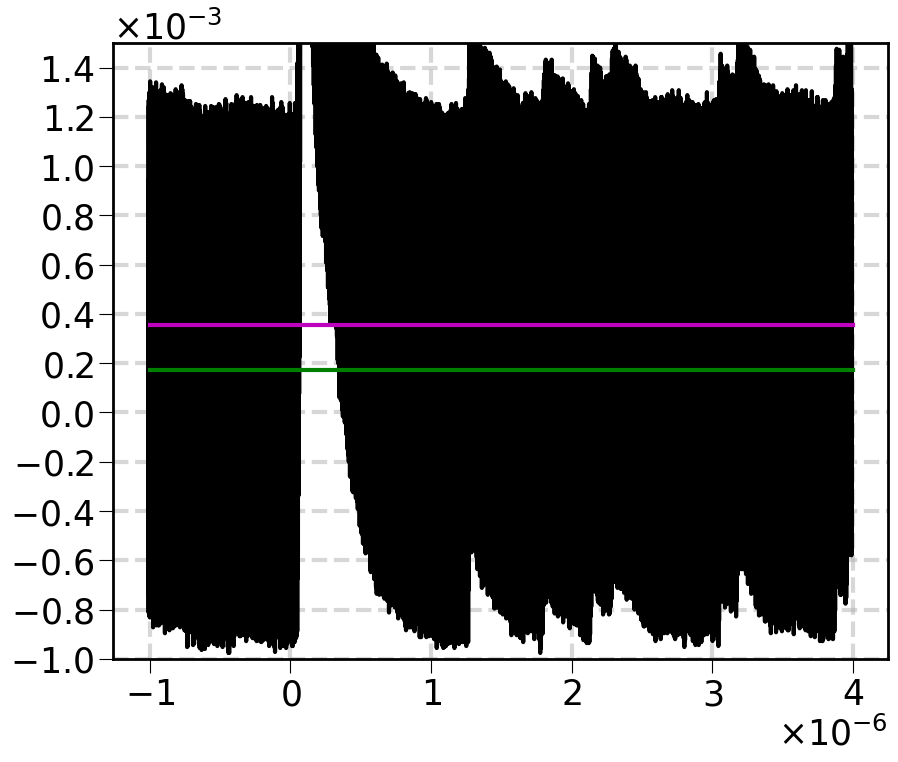

In [96]:
filenames = sorted(path_saturation.glob("*"))
for filename in filenames[2:]:
    t, wfs, led = read(filename)
    wf = wfs[1]
    m1 = np.median(wf)
    m2 = np.mean(wf[in_range(t, -1, 0)])
    plt.plot(t, wf)
    plt.plot([-1e-6, 4e-6], [m1, m1])
    plt.plot([-1e-6, 4e-6], [m2, m2])
    plt.grid()
    plt.ylim(-1e-3, 1.5e-3)
    plt.yticks(np.arange(-1e-3, 1.5e-3, 0.2e-3))
    break

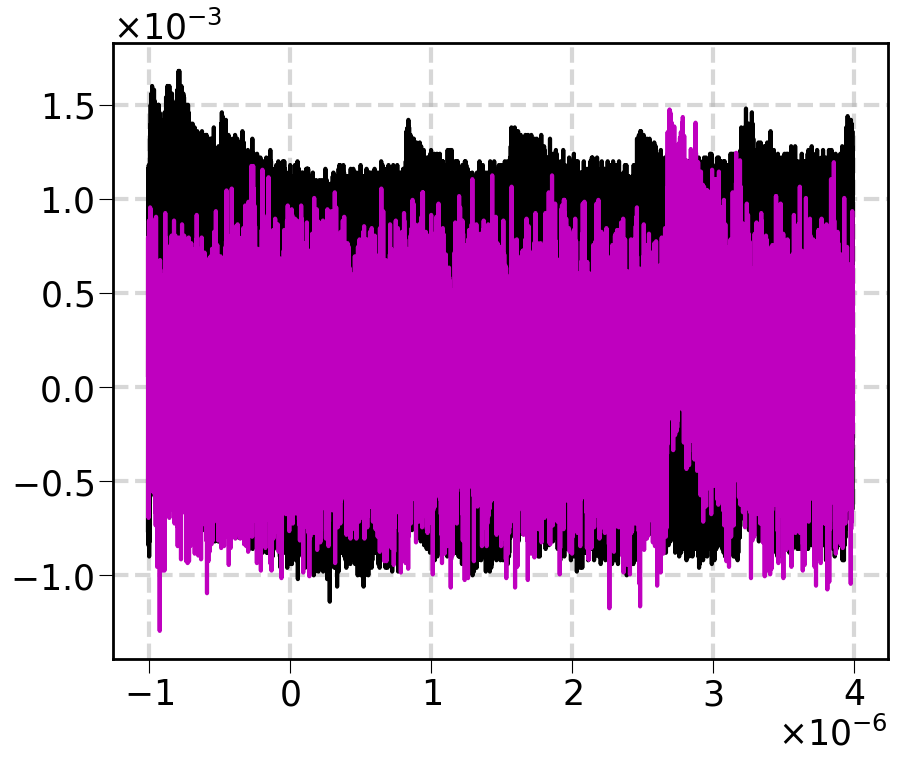

In [93]:
filenames = sorted(filter(isfile, path_hg.glob("*")))
for filename in filenames[0:]:
    t, wfs, diff, led = read(filename)
    wf = wfs[2]
    plt.plot(t, wf)
    wf = diff[2]
    wf= wf - np.median(wf[:500])
    plt.plot(t, wf)
    plt.grid()
    break

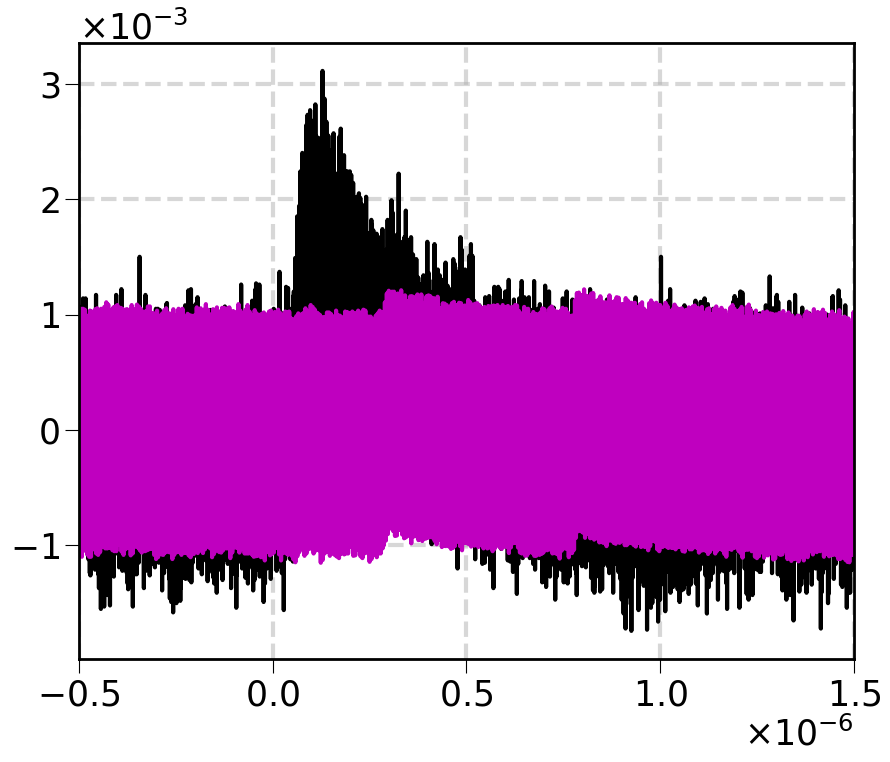

In [92]:
filenames = sorted(filter(isfile, path_mp1_hg.glob("*")))
for filename in filenames[0:]:
    t, wfs, diff, led = read(filename)
    wf = diff[1]
    wf= wf - np.median(wf[:500])
    plt.plot(t, wf)
    wf = wfs[1]
    wf= wf - np.median(wf[:500])
    plt.plot(t, wf)
    plt.grid()
    plt.xlim(-.5e-6, 1.5e-6)
    break

In [5]:
signal_window =     0, 1e-6
bline_window  = -2e-6, 0

# Saturation

In [8]:
filenames = sorted(path_saturation.glob("*"))

data = []
for filename in filenames:
    t, wfs, led = read(filename)
    integrals   = integrate_signal(t, wfs, bline_window, signal_window)
    data.append(pd.DataFrame(dict(vled=led, sipm=integrals)))

data = pd.concat(data, ignore_index=True)

saturation = data

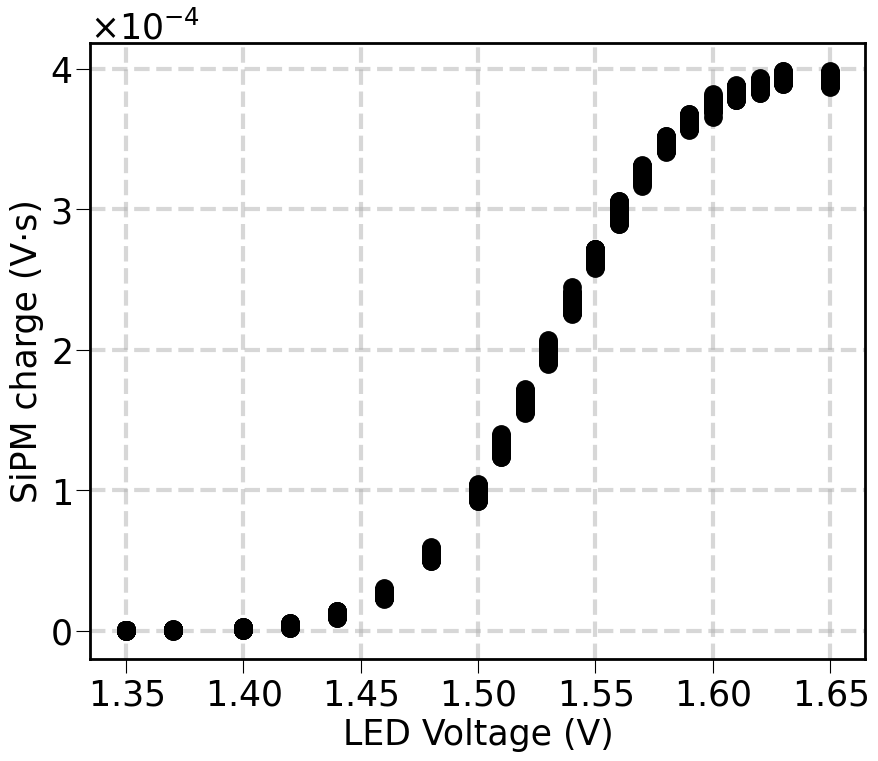

In [9]:
data = saturation

plt.plot(data.vled/1e3, data.sipm, "k.")
plt.xlabel("LED Voltage (V)")
plt.ylabel("SiPM charge (V·s)")
plt.grid()

# High gain

In [11]:
filenames = sorted(filter(isfile, path_hg.glob("*")))

data = []
for filename in filenames:
    t, raw, diff, led = read(filename)
    sipm              = integrate_signal(t,  raw, bline_window, signal_window)
    preamp            = integrate_signal(t, diff, bline_window, signal_window)
    data.append(pd.DataFrame(dict(vled=led, sipm=sipm, preamp=preamp)))

data = pd.concat(data, ignore_index=True)
data = data.assign(   sipm_sub = lambda df: df.sipm   - df.sipm.min()
                  , preamp_sub = lambda df: df.preamp - df.preamp.min() )
data = data.assign(      ratio = lambda df: df.preamp_sub / df.sipm_sub)

hg = data

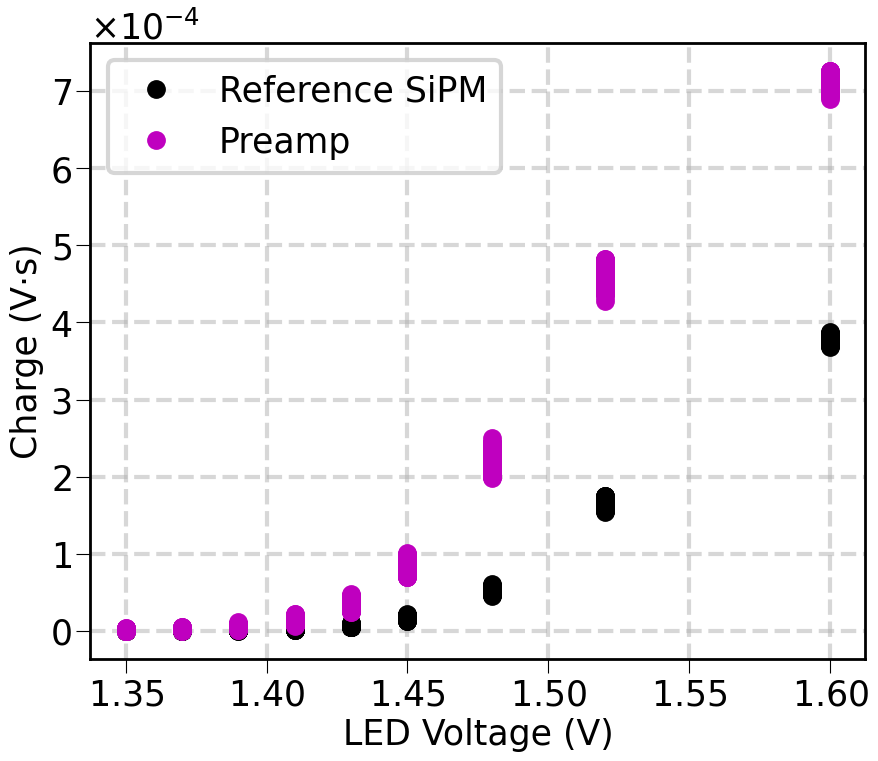

In [19]:
data = hg

plt.plot(data.vled/1e3, data.sipm_sub, "k.", label="Reference SiPM")
plt.plot(data.vled/1e3, data.preamp_sub, "m.", label="Preamp")
plt.xlabel("LED Voltage (V)")
plt.ylabel("Charge (V·s)")
plt.legend()
plt.grid()

/tmp/ipykernel_45946/3598285352.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = hg.groupby("vled").apply(mean_std).reset_index()


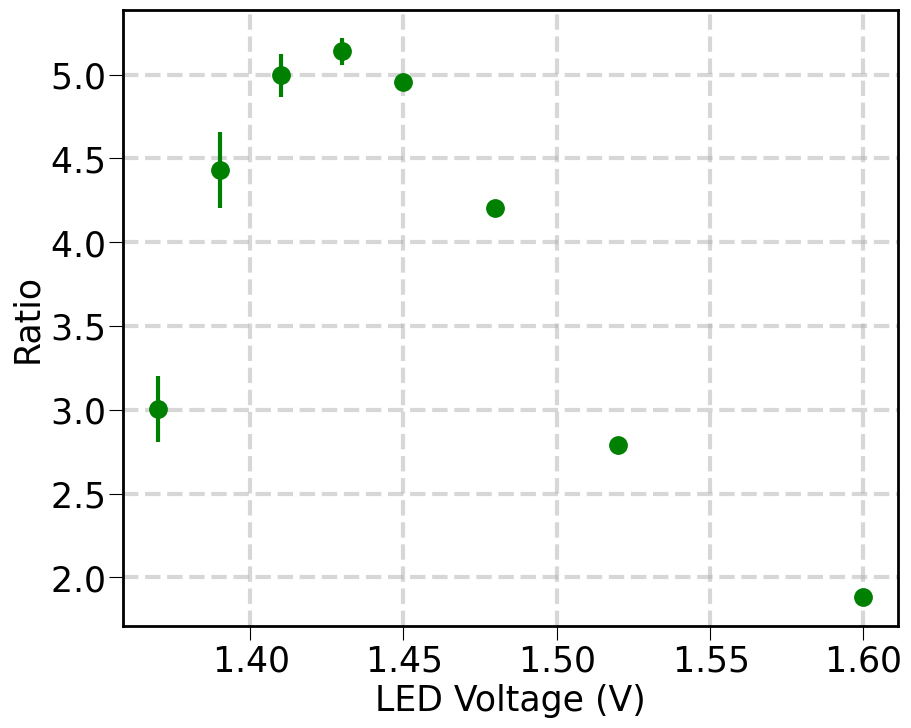

In [20]:
data = hg.groupby("vled").apply(mean_std).reset_index()

plt.errorbar(data.vled/1e3, data.average, df.uaverage * 100, fmt="g.")
plt.xlabel("LED Voltage (V)")
plt.ylabel("Ratio")
plt.grid()

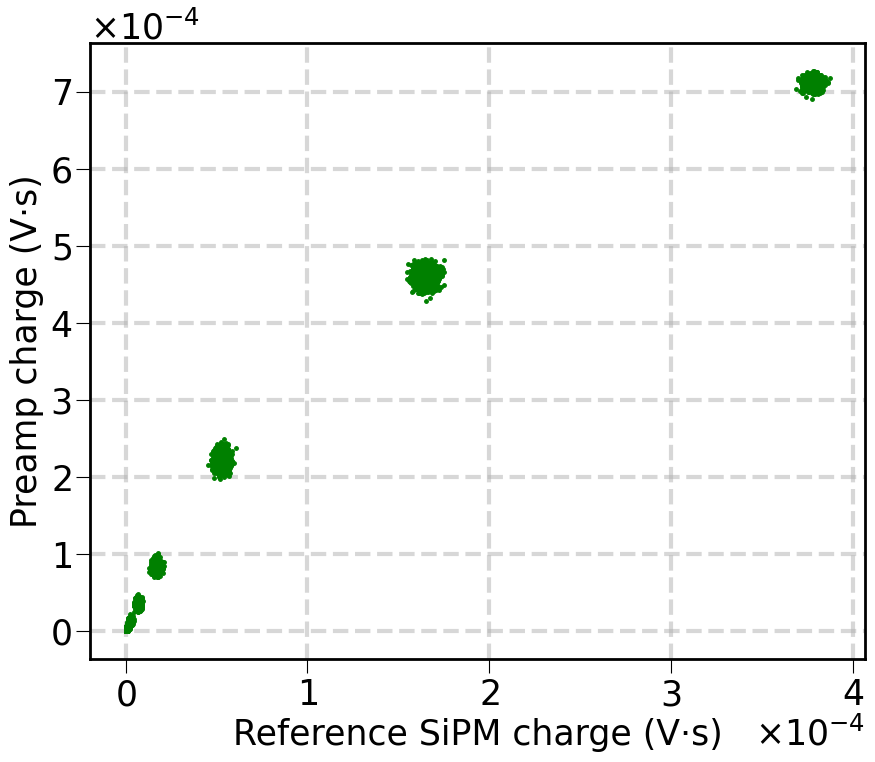

In [23]:
data = hg

plt.plot(data.sipm_sub, data.preamp_sub, "g.", ms=5)
plt.xlabel("Reference SiPM charge (V·s)")
plt.ylabel("Preamp charge (V·s)")
plt.grid()

# MP1 - LG

In [16]:
filenames = sorted(filter(isfile, path_mp1_lg.glob("*")))

data = []
for filename in filenames:
    t, raw, diff, led = read(filename)
    sipm              = integrate_signal(t,  raw, bline_window, signal_window)
    preamp            = integrate_signal(t, diff, bline_window, signal_window)
    data.append(pd.DataFrame(dict(vled=led, sipm=sipm, preamp=preamp)))

data = pd.concat(data, ignore_index=True)
data = data.assign(   sipm_sub = lambda df: df.sipm   - df.sipm.min()
                  , preamp_sub = lambda df: df.preamp - df.preamp.min() )
data = data.assign(      ratio = lambda df: df.preamp_sub / df.sipm_sub)

mp1lg = data

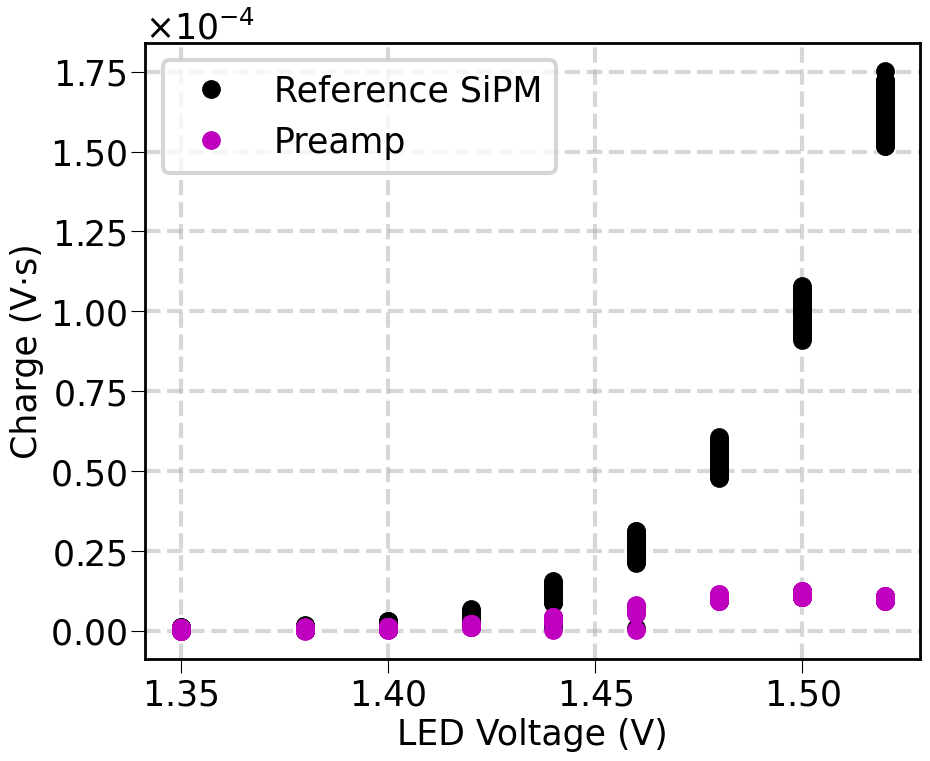

In [18]:
data = mp1lg

plt.plot(data.vled/1e3, data.sipm_sub, "k.", label="Reference SiPM")
plt.plot(data.vled/1e3, data.preamp_sub, "m.", label="Preamp")
plt.xlabel("LED Voltage (V)")
plt.ylabel("Charge (V·s)")
plt.legend()
plt.grid()

/tmp/ipykernel_45946/1137587063.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = mp1lg.groupby("vled").apply(mean_std).reset_index()


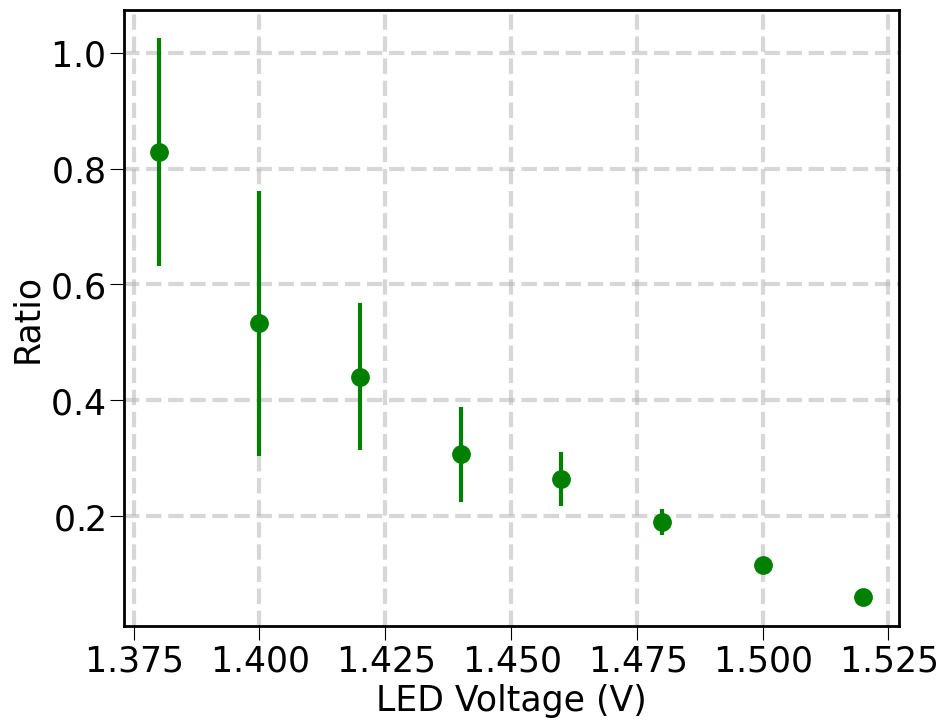

In [24]:
data = mp1lg.groupby("vled").apply(mean_std).reset_index()

plt.errorbar(data.vled/1e3, data.average, df.uaverage * 100, fmt="g.")
plt.xlabel("LED Voltage (V)")
plt.ylabel("Ratio")
plt.grid()

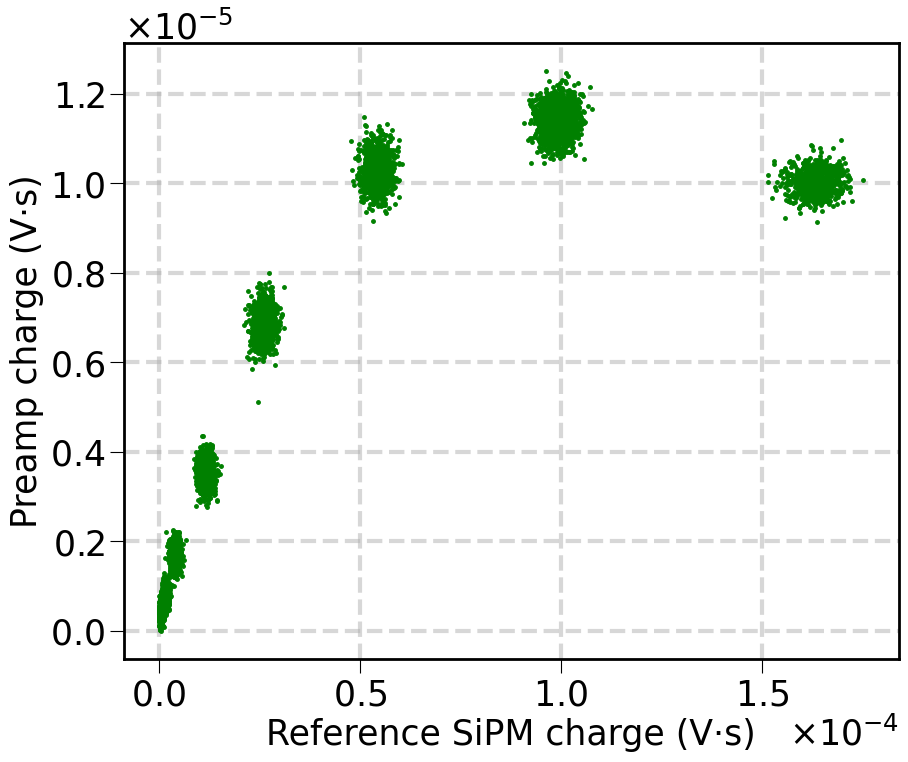

In [25]:
data = mp1lg

plt.plot(data.sipm_sub, data.preamp_sub, "g.", ms=5)
plt.xlabel("Reference SiPM charge (V·s)")
plt.ylabel("Preamp charge (V·s)")
plt.grid()

# MP1 - HG

In [34]:
filenames = sorted(filter(isfile, path_mp1_hg.glob("*")))

data = []
for filename in filenames:
    t, raw, diff, led = read(filename)
    sipm              = integrate_signal(t,  raw, bline_window, signal_window)
    preamp            = integrate_signal(t, diff, bline_window, signal_window)
    data.append(pd.DataFrame(dict(vled=led, sipm=sipm, preamp=preamp)))

data = pd.concat(data, ignore_index=True)
data = data.assign(   sipm_sub = lambda df: df.sipm   - df.sipm.min()
                  , preamp_sub = lambda df: df.preamp - df.preamp.min() )
data = data.assign(      ratio = lambda df: df.preamp_sub / df.sipm_sub)

mp1hg = data

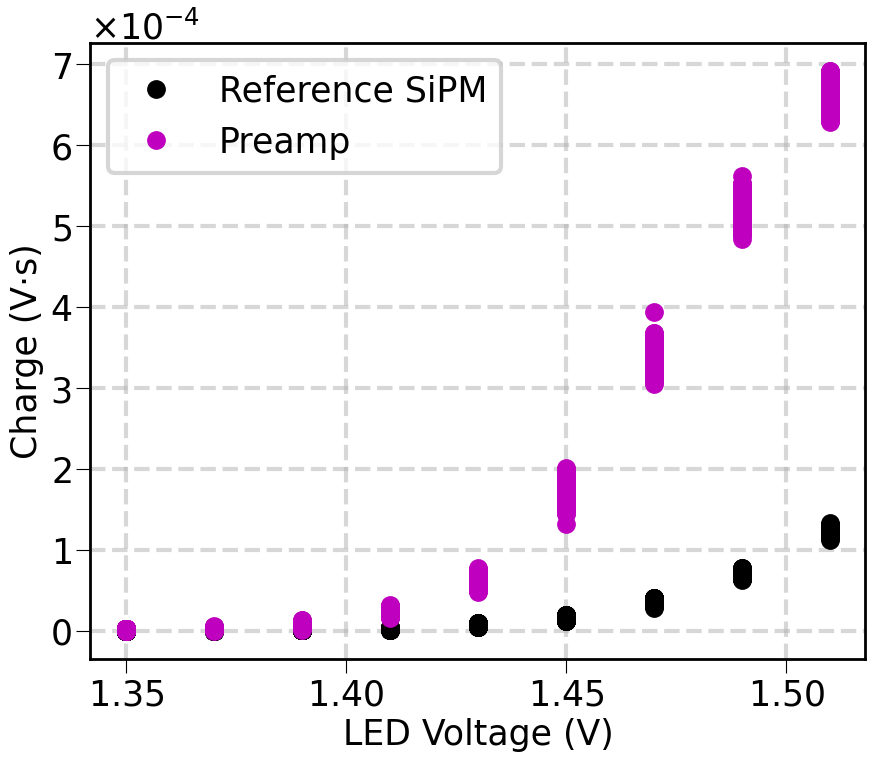

In [35]:
data = mp1hg

plt.plot(data.vled/1e3, data.sipm_sub, "k.", label="Reference SiPM")
plt.plot(data.vled/1e3, data.preamp_sub, "m.", label="Preamp")
plt.xlabel("LED Voltage (V)")
plt.ylabel("Charge (V·s)")
plt.legend()
plt.grid()

/tmp/ipykernel_45946/548721177.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = mp1hg.groupby("vled").apply(mean_std).reset_index()


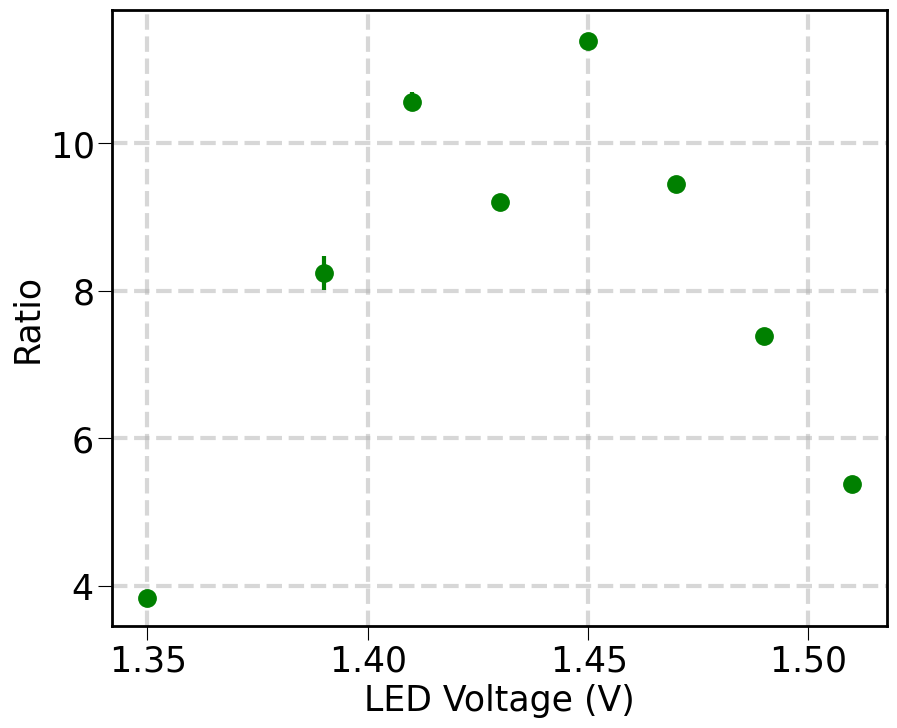

In [36]:
data = mp1hg.groupby("vled").apply(mean_std).reset_index()

plt.errorbar(data.vled/1e3, data.average, df.uaverage * 100, fmt="g.")
plt.xlabel("LED Voltage (V)")
plt.ylabel("Ratio")
plt.grid()

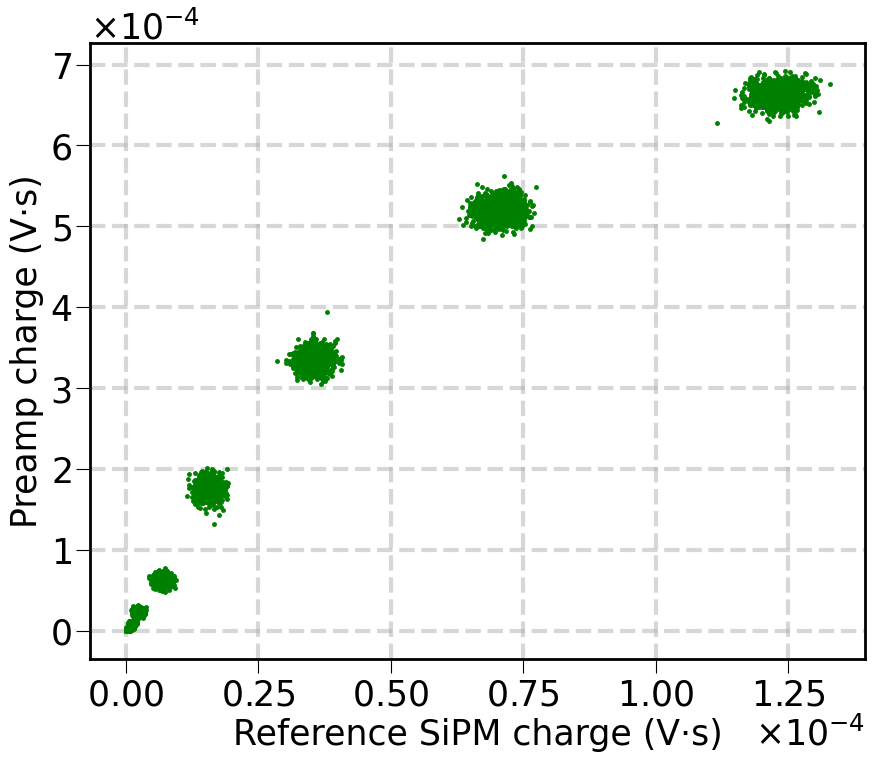

In [37]:
data = mp1hg

plt.plot(data.sipm_sub, data.preamp_sub, "g.", ms=5)
plt.xlabel("Reference SiPM charge (V·s)")
plt.ylabel("Preamp charge (V·s)")
plt.grid()

# Noise

In [65]:
dark_window = 2e-6, 4e-6
spe_window  = 0.5e-6
threshold   = 0.6e-3

In [8]:
filename = sorted(path_hg.glob("*.h5"))[0]
filename
t, raw, diff, _ = read(filename)

In [16]:
def smooth(y, n=4):
    m  = len(y)
    yf = np.flip(y)
    y  = np.concatenate([yf, y, yf])
    z  = np.ones(n) / n
    y  = np.convolve(y, z, mode="same")
    return y[m:2*m]

(2e-06, 3.75e-06)

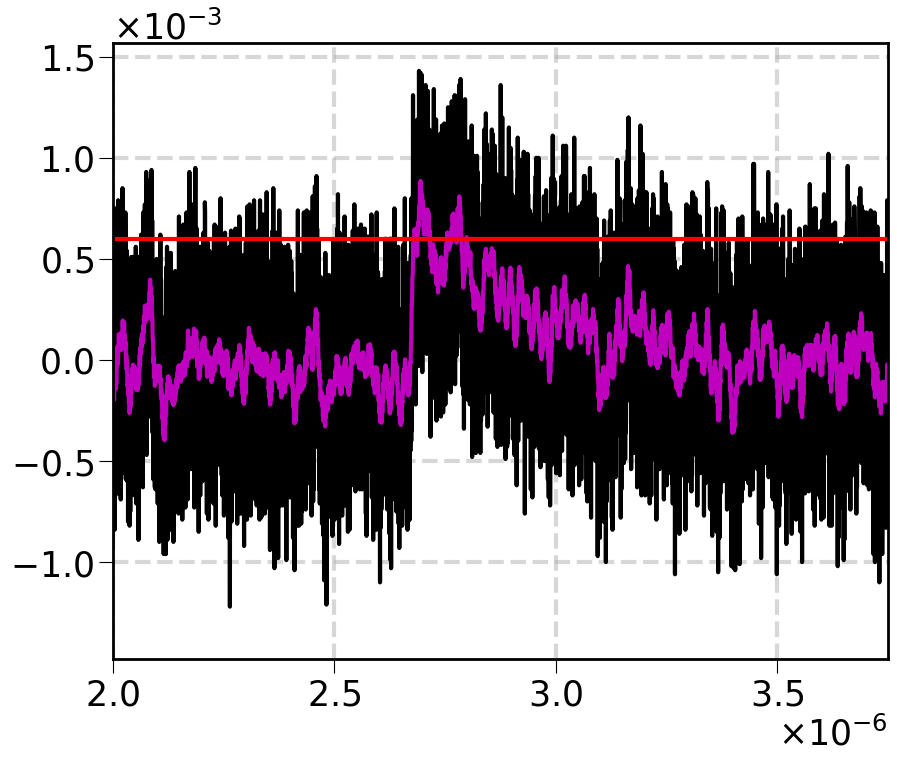

In [71]:
d = diff[2]
d = d - np.median(d)
plt.plot(t, d, "k-");

dd = smooth(d, 16)
dd = dd - np.median(dd)
plt.plot(t, dd, "m-")

plt.hlines(threshold, t.min(), t.max(), color="r")
plt.grid()
plt.xlim(2e-6, 3.75e-6)

In [75]:
def spe(t, wf, dark_window, threshold):
    sel = in_range(t, *dark_window)
    wf  = wf - np.median(wf)
    wf  = wf[sel]
    t   =  t[sel]

    t0 = -1
    spes = []
    while True:
        t0 += spe_window
        sel = (t > t0) & (wf > threshold)
        sel[0]  = False
        sel[-1] = False
        for i in range(1, len(sel)-1):
            if sel[i] and not sel[i:i+3].all():
                sel[i] = False
        if not np.count_nonzero(sel): break
        t0 = t[sel][0] - 0.05e-6
        wf_slice = wf[in_range(t-t0, 0, spe_window)]
        spes.append(wf_slice.sum() * spe_window)

    return np.asarray(spes)

In [76]:
spe(t, diff[2], dark_window, threshold)

array([1.33345e-07])

In [82]:
spes = []
for filename in sorted(path_hg.glob("*.h5"))[:5]:
    for wf in diff:
        spes.append(spe(t, wf, dark_window, threshold))
    
spes = np.concatenate(spes)

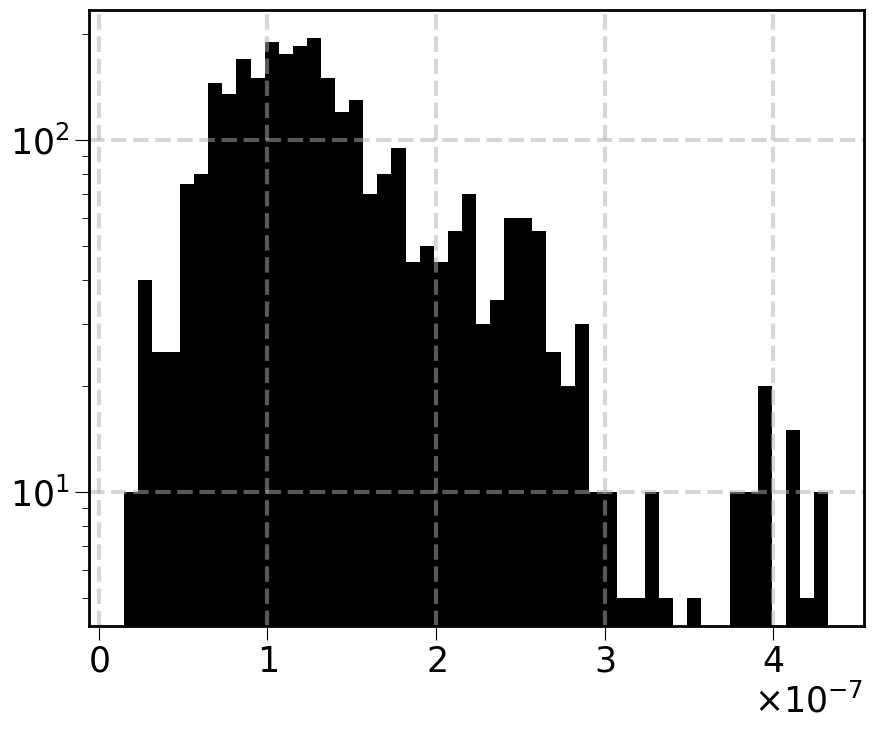

In [83]:
plt.hist(spes, 50)
plt.yscale("log")
plt.grid()